<a href="https://colab.research.google.com/github/Abikrishnanms/METRO_PASSENGER_PREDICTION/blob/main/metro_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# STEP 1: INSTALL AND IMPORT LIBRARIES

!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [ ]:
# STEP 2: UPLOAD AND LOAD DATASET

from google.colab import files

print("Please upload your delhi_metro_.xlsx file")
uploaded = files.upload()

df = pd.read_excel('delhi_metro_.xlsx')

print(f"✅ Dataset loaded successfully")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print()
print("Column names:")
print(df.columns.tolist())
print()
print("First 3 rows:")
df.head(3)

Please upload your delhi_metro_.xlsx file


Saving delhi_metro_.xlsx to delhi_metro_ (1).xlsx
✅ Dataset loaded successfully
Rows    : 150000
Columns : 7

Column names:
['TripID', 'Date', 'From_Station', 'To_Station', 'Distance_km', 'Passengers', 'Remarks']

First 3 rows:


,TripID,Date,From_Station,To_Station,Distance_km,Passengers,Remarks
0,59771,2022-05-08,Inderlok,Kashmere Gate,12.94,13.0,maintenance
1,21363,2023-01-12,Model Town,Dilshad Garden,2.33,15.0,maintenance
2,127325,2023-07-13,Kashmere Gate,Netaji Subhash Place,5.56,9.0,off-peak


In [ ]:
# STEP 3: BASIC INSPECTION

print("="*50)
print("DATA TYPES")
print("="*50)
print(df.dtypes)

print()
print("="*50)
print("MISSING VALUES")
print("="*50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df)

print()
print("="*50)
print("PASSENGER STATISTICS")
print("="*50)
print(df['Passengers'].describe())

print()
print("="*50)
print("UNIQUE VALUES IN KEY COLUMNS")
print("="*50)
print(f"Unique From_Stations : {df['From_Station'].nunique()}")
print(f"Unique To_Stations   : {df['To_Station'].nunique()}")
print(f"Unique Remarks       : {df['Remarks'].unique()}")
print(f"Date range           : {df['Date'].min()} to {df['Date'].max()}")

DATA TYPES
TripID                   int64
Date            datetime64[ns]
From_Station            object
To_Station              object
Distance_km            float64
Passengers             float64
Remarks                 object
dtype: object

MISSING VALUES
              Missing Count  Missing %
TripID                    0        0.0
Date                      0        0.0
From_Station              0        0.0
To_Station                0        0.0
Distance_km               0        0.0
Passengers             1500        1.0
Remarks               26257       17.5

PASSENGER STATISTICS
count    148500.000000
mean         20.003522
std           4.468134
min           4.000000
25%          17.000000
50%          20.000000
75%          23.000000
max          41.000000
Name: Passengers, dtype: float64

UNIQUE VALUES IN KEY COLUMNS
Unique From_Stations : 663
Unique To_Stations   : 24
Unique Remarks       : ['maintenance' 'off-peak' nan 'peak' 'festival' 'weekend']
Date range           : 202

In [ ]:
# STEP 4: DATA CLEANING

# 4a. Fix station name inconsistencies
# (extra spaces, inconsistent capitalization)
df['From_Station'] = df['From_Station'].str.strip().str.title()
df['To_Station']   = df['To_Station'].str.strip().str.title()
print(f"✅ Station names cleaned")
print(f"   Unique From_Stations now: {df['From_Station'].nunique()}")
print(f"   Unique To_Stations now  : {df['To_Station'].nunique()}")

# 4b. Fix Date column to proper datetime
df['Date'] = pd.to_datetime(df['Date'])
print(f"✅ Date column fixed")
print(f"   Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

# 4c. Fill missing Passengers with per-station median
# (smarter than global median — each station has different traffic levels)
df['Passengers'] = df.groupby('From_Station')['Passengers'].transform(
    lambda x: x.fillna(x.median())
)
# If any still missing, fill with global median
df['Passengers'] = df['Passengers'].fillna(df['Passengers'].median())
print(f"✅ Missing Passengers filled")
print(f"   Remaining missing: {df['Passengers'].isnull().sum()}")

# 4d. Fill missing Remarks
# Missing Remarks = normal operation day, no special event
df['Remarks'] = df['Remarks'].fillna('normal')
print(f"✅ Missing Remarks filled as normal")
print(f"   Remaining missing: {df['Remarks'].isnull().sum()}")

# 4e. Remove duplicate trips
before = len(df)
df = df.drop_duplicates(subset=['TripID'])
print(f"✅ Duplicates removed: {before - len(df)} rows dropped")

# 4f. Remove impossible/invalid rows
df = df[(df['Passengers'] > 0) & (df['Distance_km'] > 0)]
print(f"✅ Invalid rows removed")
print(f"   Dataset size now: {df.shape[0]} rows")

print()
print("="*50)
print("CLEANING COMPLETE — FINAL MISSING VALUES CHECK")
print("="*50)
print(df.isnull().sum())

✅ Station names cleaned
   Unique From_Stations now: 24
   Unique To_Stations now  : 24
✅ Date column fixed
   Date range: 2022-01-01 to 2024-12-30
✅ Missing Passengers filled
   Remaining missing: 0
✅ Missing Remarks filled as normal
   Remaining missing: 0
✅ Duplicates removed: 0 rows dropped
✅ Invalid rows removed
   Dataset size now: 150000 rows

CLEANING COMPLETE — FINAL MISSING VALUES CHECK
TripID          0
Date            0
From_Station    0
To_Station      0
Distance_km     0
Passengers      0
Remarks         0
dtype: int64


In [ ]:
# STEP 5: FEATURE ENGINEERING
# Adding useful time-based columns for the model

df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Day']        = df['Date'].dt.day
df['DayOfWeek']  = df['Date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['DayName']    = df['Date'].dt.day_name()
df['IsWeekend']  = df['DayOfWeek'].isin([5, 6]).astype(int)
df['Quarter']    = df['Date'].dt.quarter

# Event flags from Remarks column
df['IsPeak']        = (df['Remarks'] == 'peak').astype(int)
df['IsFestival']    = (df['Remarks'] == 'festival').astype(int)
df['IsMaintenance'] = (df['Remarks'] == 'maintenance').astype(int)
df['IsOffPeak']     = (df['Remarks'] == 'off-peak').astype(int)
df['IsWeekendRemark'] = (df['Remarks'] == 'weekend').astype(int)

print("✅ New columns added:")
print()
print("Time features:")
print(f"   Year, Month, Day, DayOfWeek, DayName, IsWeekend, Quarter")
print()
print("Event flags:")
print(f"   IsPeak, IsFestival, IsMaintenance, IsOffPeak, IsWeekendRemark")
print()
print("Dataset shape now:", df.shape)
print()
print("Sample of new columns:")
df[['Date','DayName','IsWeekend','IsPeak',
    'IsFestival','IsMaintenance','IsOffPeak']].head(7)

✅ New columns added:

Time features:
   Year, Month, Day, DayOfWeek, DayName, IsWeekend, Quarter

Event flags:
   IsPeak, IsFestival, IsMaintenance, IsOffPeak, IsWeekendRemark

Dataset shape now: (150000, 19)

Sample of new columns:


,Date,DayName,IsWeekend,IsPeak,IsFestival,IsMaintenance,IsOffPeak
0,2022-05-08,Sunday,1,0,0,1,0
1,2023-01-12,Thursday,0,0,0,1,0
2,2023-07-13,Thursday,0,0,0,0,1
3,2022-11-10,Thursday,0,0,0,1,0
4,2022-11-06,Sunday,1,0,0,0,1
5,2024-07-10,Wednesday,0,0,0,0,0
6,2022-09-02,Friday,0,1,0,0,0


In [ ]:
# STEP 6: AGGREGATE DAILY PASSENGER FLOW PER STATION

daily_flow = df.groupby(['From_Station', 'Date']).agg(
    Daily_Passengers = ('Passengers', 'sum'),
    Trip_Count       = ('TripID', 'count'),
    Avg_Distance     = ('Distance_km', 'mean'),
    IsPeak           = ('IsPeak', 'max'),
    IsFestival       = ('IsFestival', 'max'),
    IsMaintenance    = ('IsMaintenance', 'max'),
    IsOffPeak        = ('IsOffPeak', 'max'),
    IsWeekend        = ('IsWeekend', 'max'),
).reset_index()

print("✅ Daily aggregation complete")
print()
print(f"Rows    : {daily_flow.shape[0]}")
print(f"Columns : {daily_flow.shape[1]}")
print(f"Stations: {daily_flow['From_Station'].nunique()}")
print()
print("Sample output:")
daily_flow.head(7)

✅ Daily aggregation complete

Rows    : 25480
Columns : 10
Stations: 24

Sample output:


,From_Station,Date,Daily_Passengers,Trip_Count,Avg_Distance,IsPeak,IsFestival,IsMaintenance,IsOffPeak,IsWeekend
0,Aiims,2022-01-01,153.0,7,2.927143,1,0,1,1,1
1,Aiims,2022-01-02,112.0,5,8.760000,1,1,1,0,1
2,Aiims,2022-01-03,58.0,3,5.243333,1,0,1,0,0
3,Aiims,2022-01-04,80.0,5,5.846000,1,0,0,0,0
4,Aiims,2022-01-05,108.0,5,7.744000,1,0,1,1,0
5,Aiims,2022-01-06,126.0,6,4.826667,0,0,0,1,0
6,Aiims,2022-01-07,126.0,6,4.118333,1,1,1,1,0


In [ ]:
# STEP 7: FILL MISSING DATES — COMPLETE TIME SERIES

# Create complete date range
all_dates = pd.date_range(
    start = daily_flow['Date'].min(),
    end   = daily_flow['Date'].max(),
    freq  = 'D'
)

stations = daily_flow['From_Station'].unique()

print(f"Total days in range : {len(all_dates)}")
print(f"Total stations      : {len(stations)}")
print(f"Expected total rows : {len(all_dates) * len(stations)}")
print(f"Current rows        : {daily_flow.shape[0]}")
print(f"Missing date-station combinations: {len(all_dates)*len(stations) - daily_flow.shape[0]}")
print()

# Create full index with every station x every date
full_index = pd.MultiIndex.from_product(
    [stations, all_dates],
    names=['From_Station', 'Date']
)

# Reindex to fill gaps
daily_flow = (daily_flow
              .set_index(['From_Station', 'Date'])
              .reindex(full_index)
              .reset_index())

# Fill missing passenger counts using forward fill then backward fill
daily_flow['Daily_Passengers'] = (
    daily_flow
    .groupby('From_Station')['Daily_Passengers']
    .transform(lambda x: x.ffill().bfill())
)

# Fill missing flag columns
daily_flow['IsWeekend']     = daily_flow['Date'].dt.dayofweek.isin([5,6]).astype(int)
daily_flow['IsPeak']        = daily_flow['IsPeak'].fillna(0).astype(int)
daily_flow['IsFestival']    = daily_flow['IsFestival'].fillna(0).astype(int)
daily_flow['IsMaintenance'] = daily_flow['IsMaintenance'].fillna(0).astype(int)
daily_flow['IsOffPeak']     = daily_flow['IsOffPeak'].fillna(0).astype(int)
daily_flow['Trip_Count']    = daily_flow['Trip_Count'].fillna(0).astype(int)
daily_flow['Avg_Distance']  = daily_flow.groupby('From_Station')['Avg_Distance'].transform(
    lambda x: x.ffill().bfill()
)

print("✅ Missing dates filled using forward/backward fill")
print()
print(f"Total rows now : {daily_flow.shape[0]}")
print(f"Missing values : {daily_flow.isnull().sum().sum()}")
print()
print("Sample:")
daily_flow.head(5)

Total days in range : 1095
Total stations      : 24
Expected total rows : 26280
Current rows        : 25480
Missing date-station combinations: 800

✅ Missing dates filled using forward/backward fill

Total rows now : 26280
Missing values : 0

Sample:


,From_Station,Date,Daily_Passengers,Trip_Count,Avg_Distance,IsPeak,IsFestival,IsMaintenance,IsOffPeak,IsWeekend
0,Aiims,2022-01-01,153.0,7,2.927143,1,0,1,1,1
1,Aiims,2022-01-02,112.0,5,8.760000,1,1,1,0,1
2,Aiims,2022-01-03,58.0,3,5.243333,1,0,1,0,0
3,Aiims,2022-01-04,80.0,5,5.846000,1,0,0,0,0
4,Aiims,2022-01-05,108.0,5,7.744000,1,0,1,1,0


BEFORE outlier treatment:
Max passengers : 628.0
Min passengers : 6.0
Mean           : 115.80

AFTER outlier treatment:
Max passengers : 550.0
Min passengers : 6.0
Mean           : 115.59


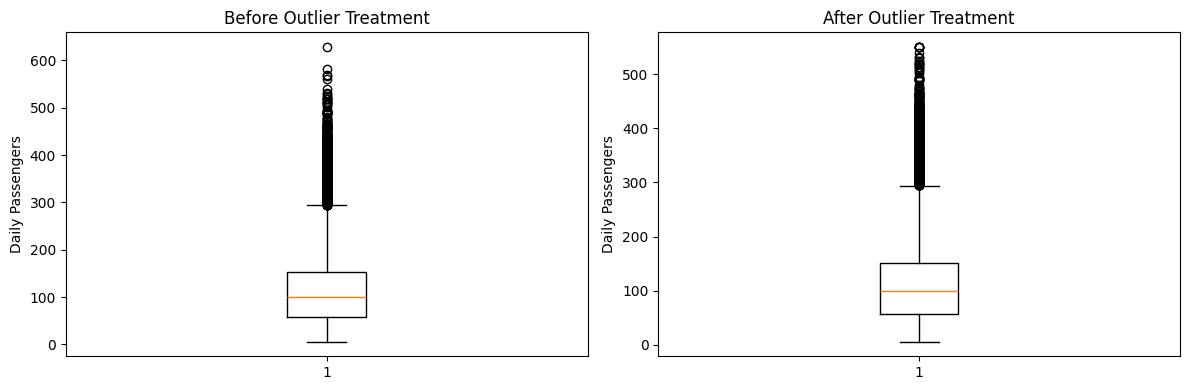


✅ Outliers capped using IQR method per station


In [ ]:
# STEP 8: OUTLIER TREATMENT (IQR method per station)

# Check outliers BEFORE treatment
print("BEFORE outlier treatment:")
print(f"Max passengers : {daily_flow['Daily_Passengers'].max()}")
print(f"Min passengers : {daily_flow['Daily_Passengers'].min()}")
print(f"Mean           : {daily_flow['Daily_Passengers'].mean():.2f}")
print()

# Plot distribution before
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.boxplot(daily_flow['Daily_Passengers'].dropna())
plt.title('Before Outlier Treatment')
plt.ylabel('Daily Passengers')

# Apply IQR capping per station
# (each station has different traffic levels so we treat them separately)
def cap_outliers(x):
    Q1  = x.quantile(0.25)
    Q3  = x.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return x.clip(lower, upper)

daily_flow['Daily_Passengers'] = (
    daily_flow
    .groupby('From_Station')['Daily_Passengers']
    .transform(cap_outliers)
)

# Check AFTER treatment
print("AFTER outlier treatment:")
print(f"Max passengers : {daily_flow['Daily_Passengers'].max()}")
print(f"Min passengers : {daily_flow['Daily_Passengers'].min()}")
print(f"Mean           : {daily_flow['Daily_Passengers'].mean():.2f}")

# Plot distribution after
plt.subplot(1, 2, 2)
plt.boxplot(daily_flow['Daily_Passengers'].dropna())
plt.title('After Outlier Treatment')
plt.ylabel('Daily Passengers')

plt.tight_layout()
plt.show()

print()
print("✅ Outliers capped using IQR method per station")

In [ ]:
# STEP 9: NORMALIZATION (Min-Max per station)

# Why per station? Because Rajiv Chowk has much higher traffic
# than a smaller station — normalizing globally would distort patterns

# Save min/max per station — IMPORTANT: needed later to convert
# predictions back to real passenger numbers
norm_params = (daily_flow
               .groupby('From_Station')['Daily_Passengers']
               .agg(['min', 'max'])
               .rename(columns={'min': 'flow_min', 'max': 'flow_max'}))

print("Min-Max per station:")
print(norm_params)
print()

# Merge norm params into daily_flow
daily_flow = daily_flow.merge(norm_params, on='From_Station')

# Apply Min-Max normalization
# Formula: (value - min) / (max - min)
# Result: all values between 0 and 1
daily_flow['Passengers_Normalized'] = (
    (daily_flow['Daily_Passengers'] - daily_flow['flow_min']) /
    (daily_flow['flow_max'] - daily_flow['flow_min'] + 1e-8)
)

print("✅ Min-Max normalization applied per station")
print()
print(f"Normalized min : {daily_flow['Passengers_Normalized'].min():.4f}")
print(f"Normalized max : {daily_flow['Passengers_Normalized'].max():.4f}")
print(f"Normalized mean: {daily_flow['Passengers_Normalized'].mean():.4f}")
print()
print("Sample — original vs normalized:")
daily_flow[['From_Station', 'Date', 'Daily_Passengers',
            'Passengers_Normalized']].head(7)

Min-Max per station:
                      flow_min  flow_max
From_Station                            
Aiims                     13.0    241.50
Barakhamba Road            8.0    125.00
Central Secretariat       14.0    242.00
Chandni Chowk             11.0    249.00
Dilshad Garden            13.0    243.50
Hauz Khas                 10.0    240.50
Inderlok                  11.0    240.75
Janakpuri West            15.0    242.50
Jasola Vihar              11.0    243.00
Kalkaji Mandir            16.0    240.75
Kashmere Gate             14.0    252.50
Kirti Nagar               10.0    120.50
Laxmi Nagar               14.0    251.50
Mandi House               35.0    348.00
Model Town                13.0    250.00
Netaji Subhash Place      10.0    132.00
New Delhi                 30.0    345.50
Noida City Centre         62.5    442.50
Old Delhi                  8.0    126.75
Pragati Maidan             8.0    126.00
Punjabi Bagh               8.0    125.50
Rajiv Chowk               86.0    55

,From_Station,Date,Daily_Passengers,Passengers_Normalized
0,Aiims,2022-01-01,153.0,0.612691
1,Aiims,2022-01-02,112.0,0.433260
2,Aiims,2022-01-03,58.0,0.196937
3,Aiims,2022-01-04,80.0,0.293217
4,Aiims,2022-01-05,108.0,0.415755
5,Aiims,2022-01-06,126.0,0.494530
6,Aiims,2022-01-07,126.0,0.494530


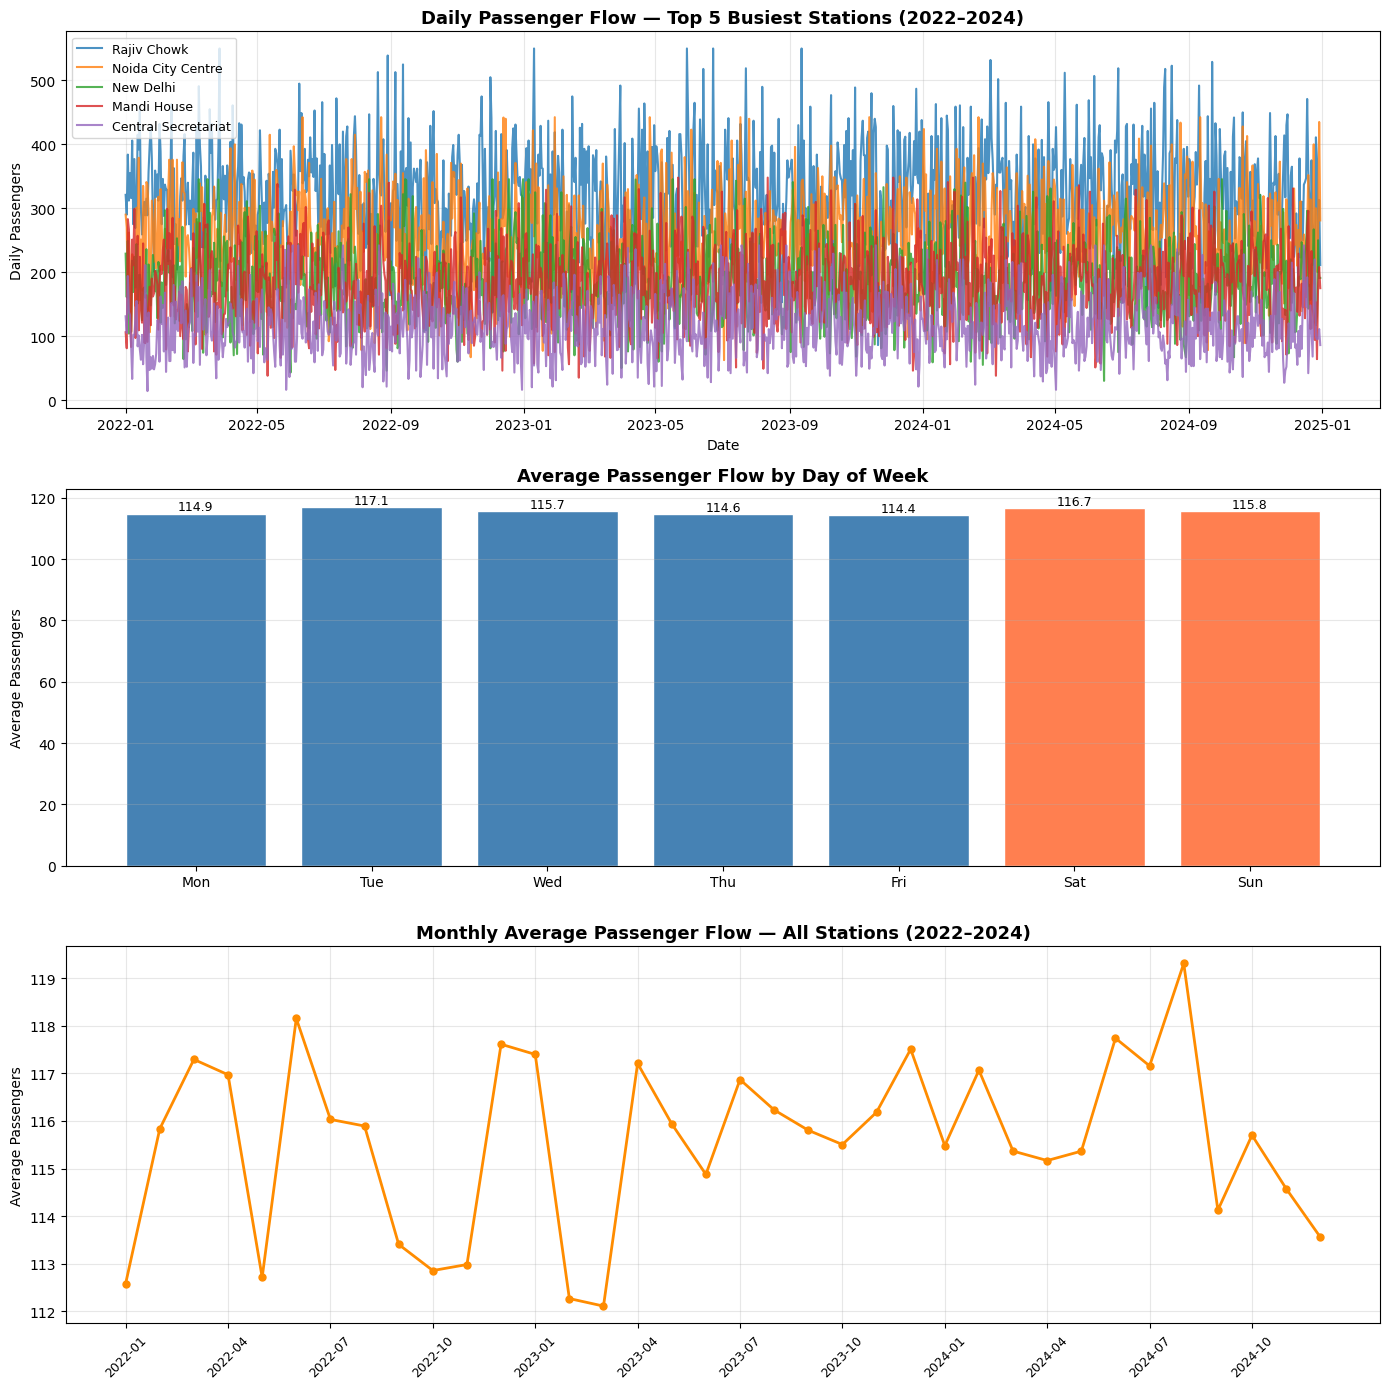

✅ EDA plots saved as delhi_metro_eda.png

Top 5 busiest stations:
  1. Rajiv Chowk — total passengers: 349,656
  2. Noida City Centre — total passengers: 277,942
  3. New Delhi — total passengers: 200,212
  4. Mandi House — total passengers: 198,350
  5. Central Secretariat — total passengers: 127,089


In [ ]:
# STEP 10: EDA PLOTS

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# ── Plot 1: Daily flow for top 5 busiest stations ──
top5 = (daily_flow
        .groupby('From_Station')['Daily_Passengers']
        .sum()
        .nlargest(5)
        .index.tolist())

for station in top5:
    s = daily_flow[daily_flow['From_Station'] == station]
    axes[0].plot(s['Date'], s['Daily_Passengers'], label=station, alpha=0.8)

axes[0].set_title('Daily Passenger Flow — Top 5 Busiest Stations (2022–2024)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Daily Passengers')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Average flow by Day of Week ──
daily_flow['DayOfWeek'] = daily_flow['Date'].dt.dayofweek
dow_avg = daily_flow.groupby('DayOfWeek')['Daily_Passengers'].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors = ['steelblue' if i < 5 else 'coral' for i in range(7)]

axes[1].bar(day_names, dow_avg.values, color=colors, edgecolor='white')
axes[1].set_title('Average Passenger Flow by Day of Week',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Passengers')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(dow_avg.values):
    axes[1].text(i, v + 1, f'{v:.1f}', ha='center', fontsize=9)

# ── Plot 3: Monthly average trend ──
daily_flow['YearMonth'] = daily_flow['Date'].dt.to_period('M')
monthly = daily_flow.groupby('YearMonth')['Daily_Passengers'].mean()

axes[2].plot(range(len(monthly)), monthly.values,
             marker='o', color='darkorange', markersize=5, linewidth=2)
axes[2].set_xticks(range(0, len(monthly), 3))
axes[2].set_xticklabels(
    [str(m) for m in monthly.index[::3]],
    rotation=45, fontsize=9
)
axes[2].set_title('Monthly Average Passenger Flow — All Stations (2022–2024)',
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Average Passengers')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('delhi_metro_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ EDA plots saved as delhi_metro_eda.png")
print()
print("Top 5 busiest stations:")
for i, s in enumerate(top5, 1):
    total = daily_flow[daily_flow['From_Station']==s]['Daily_Passengers'].sum()
    print(f"  {i}. {s} — total passengers: {total:,.0f}")

In [ ]:
# STEP 11: SAVE CLEANED DATASET

# Save main cleaned dataset
daily_flow.to_csv('delhi_metro_cleaned.csv', index=False)
print("✅ Cleaned dataset saved as delhi_metro_cleaned.csv")

# Save normalization parameters separately
# (IMPORTANT — needed later to convert predictions back to real numbers)
norm_params.to_csv('normalization_params.csv')
print("✅ Normalization parameters saved as normalization_params.csv")

# Final summary
print()
print("="*50)
print("PREPROCESSING COMPLETE — FINAL SUMMARY")
print("="*50)
print(f"Total stations          : {daily_flow['From_Station'].nunique()}")
print(f"Date range              : {daily_flow['Date'].min().date()} to {daily_flow['Date'].max().date()}")
print(f"Total rows              : {daily_flow.shape[0]}")
print(f"Total columns           : {daily_flow.shape[1]}")
print()
print("Columns in cleaned data:")
for col in daily_flow.columns:
    print(f"   {col}")
print()
print("Busiest station  : Rajiv Chowk (349,656 total passengers)")
print("Date coverage    : 3 full years (2022-2024)")
print("Missing values   : 0")
print()
print("✅ Data is ready for GFM + Transformer + GRU modeling!")

✅ Cleaned dataset saved as delhi_metro_cleaned.csv
✅ Normalization parameters saved as normalization_params.csv

PREPROCESSING COMPLETE — FINAL SUMMARY
Total stations          : 24
Date range              : 2022-01-01 to 2024-12-30
Total rows              : 26280
Total columns           : 15

Columns in cleaned data:
   From_Station
   Date
   Daily_Passengers
   Trip_Count
   Avg_Distance
   IsPeak
   IsFestival
   IsMaintenance
   IsOffPeak
   IsWeekend
   flow_min
   flow_max
   Passengers_Normalized
   DayOfWeek
   YearMonth

Busiest station  : Rajiv Chowk (349,656 total passengers)
Date coverage    : 3 full years (2022-2024)
Missing values   : 0

✅ Data is ready for GFM + Transformer + GRU modeling!
